In [8]:
import torch
import torchvision.transforms as T
from torchvision.models import resnet18
from PIL import Image
import json
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

from torchcam.methods import SmoothGradCAMpp

# Load model
model = resnet18(weights="IMAGENET1K_V1")
model.eval()

# Load class index mapping
with open("imagenet_class_index.json", "r") as f:
    idx_to_class = json.load(f)

# Preprocessing
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return img, transform(img).unsqueeze(0)

# CAM method
cam_extractor = SmoothGradCAMpp(model)

def generate_cam(image_path):
    img, input_tensor = load_image(image_path)

    # Forward pass
    out = model(input_tensor)
    class_idx = out.argmax().item()
    class_name = idx_to_class[str(class_idx)][1]

    # CAM
    cams = cam_extractor(class_idx, out)
    cam = cams[0][0].detach().unsqueeze(0).unsqueeze(0)  # shape: (1,1,224,224)

    # Resize CAM to match image size using PyTorch
    cam_resized = F.interpolate(cam, size=(800, 800), mode="bilinear", align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    # Normalize CAM
    cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min())

    # Resize image
    img_resized = img.resize((800, 800))

    # Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(img_resized))
    plt.imshow(cam_resized, cmap="jet", alpha=0.4)
    plt.title(f"Predicted: {class_name}")
    plt.axis("off")
    plt.show()

      # SAVE CAM IMAGE AUTOMATICALLY
    plt.savefig(f"{image_path}_cam.png", bbox_inches='tight')

    plt.show()

    return out, class_idx, class_name




Processing: images/dog_pos.jpg


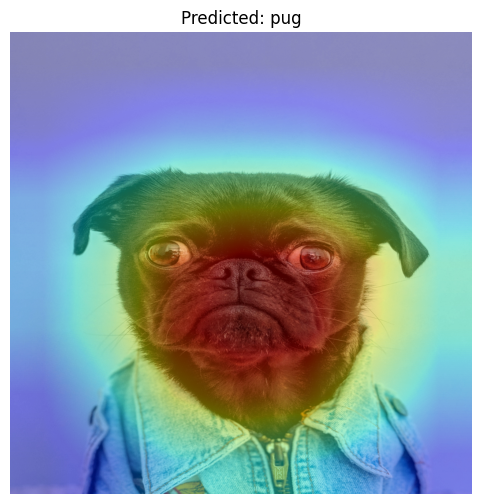

Processing: images/dog_neg.jpg


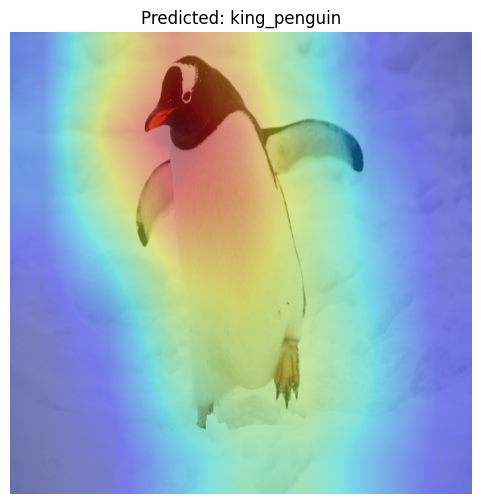

Processing: images/cat_pos.jpg


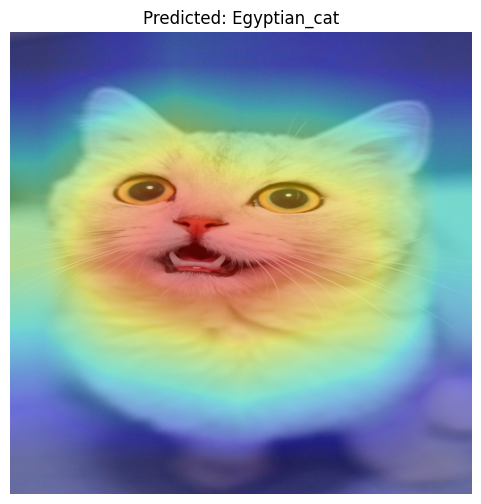

Processing: images/cat_neg.jpg


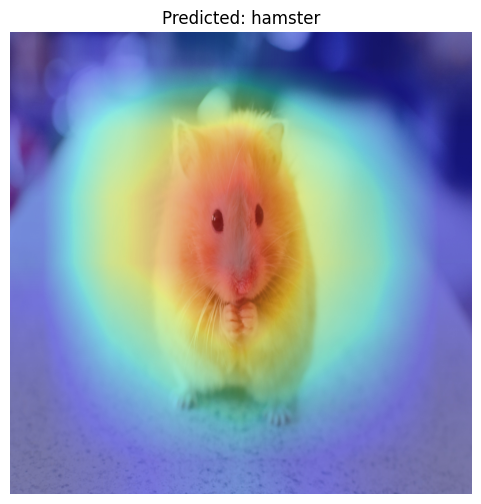

Processing: images/car_pos.jpg


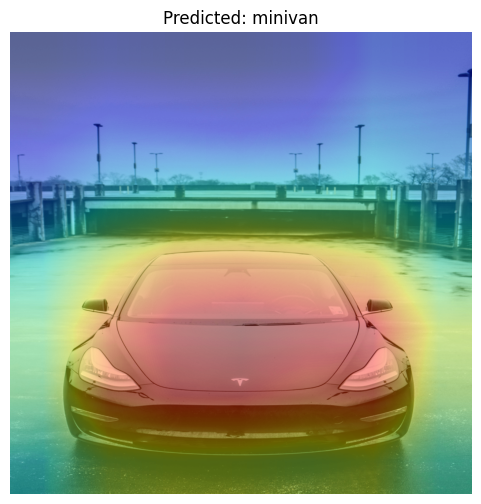

Processing: images/car_neg.jpg


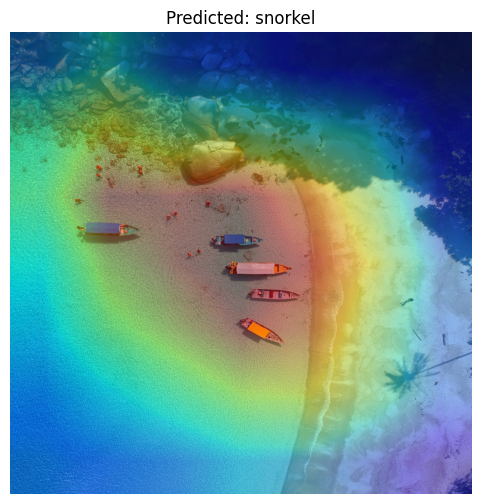

In [4]:
paths = [
    "images/dog_pos.jpg",
    "images/dog_neg.jpg",
    "images/cat_pos.jpg",
    "images/cat_neg.jpg",
    "images/car_pos.jpg",
    "images/car_neg.jpg"
]

results = {}

for p in paths:
    print("Processing:", p)
    logits, idx, name = generate_cam(p)
    results[p] = (logits, idx, name)
